# Targeted Promotion Incrementality Analysis

## Objective
Estimate the incremental revenue impact of a 10% targeted discount for high-LTV users using a randomized A/B experiment.

This analysis includes:
- Post-period Average Treatment Effect (ATE)
- Confidence intervals
- Difference-in-Differences (DiD)
- Fixed Effects panel estimation
- Cluster-robust inference

## Key Findings

- Post-period ATE lift: **+$28.50 per user**
- 95% CI: [$23.90, $33.11] — statistically significant
- Percent lift: **+8.16%** 

Robust Difference-in-Differences estimates confirm incremental impact:

- Clustered DiD weekly lift: **+$8.74**
- Fixed-effects DiD weekly lift: **+$4.53**
- FE DiD implied 6-week lift ≈ $4.53 × 6 = $27.18 (consistent with ATE) — strengthens causal credibility

Even under conservative fixed-effects specifications, the 10% targeted discount generates economically meaningful incremental revenue among high-LTV users.

Note: Post-period ATE reflects total 6-week lift per user. DiD estimates represent incremental weekly revenue impact.

## Experiment Design

**Population**
- High-LTV users identified prior to experiment launch
- 55,102 eligible users included in post-period analysis
- Randomized at the user level

**Treatment**
- 10% targeted discount offered to treatment group
- Control group received no promotional discount

**Randomization**
- Deterministic user-level assignment
- Balanced treatment and control groups (validated via pre-period checks)

**Outcome Metric**
- Revenue per user (post-period)
- Weekly revenue for panel-based DiD analysis

**Time Window**
- 6-week pre-period (baseline)
- 6-week post-period (treatment exposure)

**Identification Strategy**
- Causal effect estimated using post-period ATE and Difference-in-Differences to control for time trends.

## Assumptions & Validity

- Randomization ensures treatment exogeneity
- Parallel trends assumption evaluated via pre/post visualization
- Cluster-robust standard errors used to account for within-user correlation
- Fixed effects remove time-invariant user heterogeneity

## 1. Environment & Setup

Load dependencies and establish a secure database connection using environment variables.

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
import psycopg2

# Load environment variables from .env
load_dotenv()

conn = psycopg2.connect(
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
)


In [2]:
def coef_line(model, term="interaction"):
    b = model.params[term]
    se = model.bse[term]
    p = model.pvalues[term]
    ci_low, ci_high = model.conf_int().loc[term]
    return {
        "coef": round(b, 2),
        "se": round(se, 3),
        "p": p,
        "ci_low": round(ci_low, 2),
        "ci_high": round(ci_high, 2)
    }

## 2. Post-Period Aggregated Data

Pull user-level post-period revenue summary for eligible high-LTV users.

This dataset contains:
- `user_id`
- `treatment_flag`
- `post_revenue`

Used to estimate the primary post-period Average Treatment Effect (ATE).

In [3]:
query = """
select *
from analysis.post_user_summary
"""

df = pd.read_sql(query, conn)

df.head()

C:\Users\trist\AppData\Local\Temp\ipykernel_13684\960220042.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,user_id,treatment_flag,post_revenue
0,2,1,318.3516
1,10,1,662.5908
2,11,0,64.0100
3,17,0,327.7300
4,19,0,442.8600


In [4]:
len(df)

55102

**Sample Size:** 55,102 high-LTV users

## 3. Primary Result: Post-Period ATE

We estimate the Average Treatment Effect (ATE) using a two-sample t-test
comparing treatment and control post-period revenue.

In [5]:
import numpy as np
import pandas as pd

treat = df.loc[df["treatment_flag"] == 1, "post_revenue"]
ctrl  = df.loc[df["treatment_flag"] == 0, "post_revenue"]

treat_mean = treat.mean()
ctrl_mean  = ctrl.mean()
lift = treat_mean - ctrl_mean
pct_lift = (lift / ctrl_mean) * 100

se = np.sqrt(treat.var(ddof=1)/len(treat) + ctrl.var(ddof=1)/len(ctrl))
ci_low  = lift - 1.96 * se
ci_high = lift + 1.96 * se

results_summary = pd.DataFrame({
    "Metric": ["Control Mean (Post)", "Treatment Mean (Post)", "ATE Lift ($)", "Percent Lift (%)", "95% CI Low", "95% CI High"],
    "Value":  [ctrl_mean, treat_mean, lift, pct_lift, ci_low, ci_high]
})

results_summary["Value"] = results_summary["Value"].round(4)
results_summary

,Metric,Value
0,Control Mean (Post),349.3741
1,Treatment Mean (Post),377.8744
2,ATE Lift ($),28.5002
3,Percent Lift (%),8.1575
4,95% CI Low,23.8953
5,95% CI High,33.1052


**Interpretation:**

Post-period ATE lift: +$28.50 per user (+8.16%)

95% CI: [$23.90, $33.11] → statistically significant (CI does not include 0)

## 4. Confidence Interval Estimation

Compute standard error and 95% confidence interval for the estimated lift.

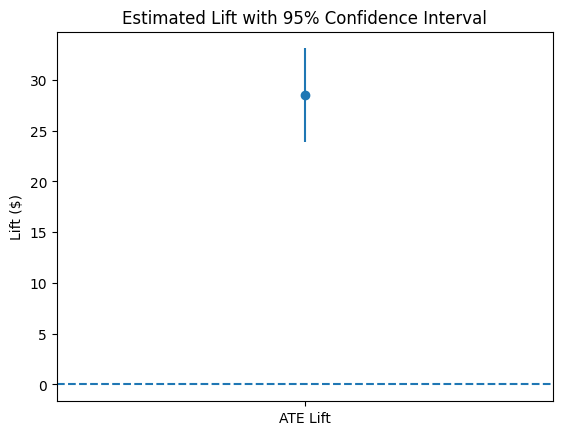

In [6]:
import matplotlib.pyplot as plt

err_low  = lift - ci_low
err_high = ci_high - lift

plt.figure()
plt.errorbar(
    x=[0],
    y=[lift],
    yerr=[[err_low], [err_high]],
    fmt="o"
);
plt.xticks([0], ["ATE Lift"])
plt.axhline(0, linestyle='--')
plt.ylabel("Lift ($)")
plt.title("Estimated Lift with 95% Confidence Interval")
plt.show()

The 95% confidence interval does not cross 0, indicating statistical significance at the 5% level.

## 5. Post-Period Revenue Comparison

Visual comparison of mean post-period revenue per user.

In [7]:
treatment = df[df["treatment_flag"] == 1]["post_revenue"]
control = df[df["treatment_flag"] == 0]["post_revenue"]

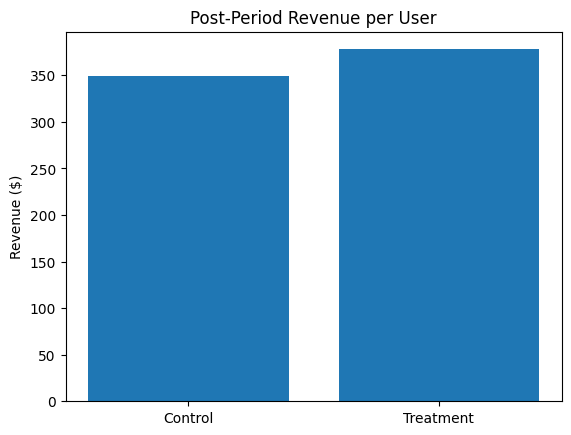

In [8]:
import matplotlib.pyplot as plt

treatment_mean = treatment.mean()
control_mean = control.mean()

plt.figure()
plt.bar(["Control", "Treatment"], [control_mean, treatment_mean])
plt.title("Post-Period Revenue per User")
plt.ylabel("Revenue ($)")
plt.show()

## 6. Panel Dataset Construction

Construct user-week panel data (pre vs post) for high-LTV users to enable Difference-in-Differences estimation.

In [9]:
query = """
select
    user_id,
    treatment_flag,
    high_ltv_flag,
    pre_post_flag,
    revenue_sim
from marts.mart_user_week_experiment_sim
where high_ltv_flag = 1
  and pre_post_flag in ('pre','post')
"""

panel_df = pd.read_sql(query, conn)

panel_df.head()

C:\Users\trist\AppData\Local\Temp\ipykernel_13684\2673839738.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  panel_df = pd.read_sql(query, conn)


,user_id,treatment_flag,high_ltv_flag,pre_post_flag,revenue_sim
0,27,0,1,pre,55.20
1,27,0,1,pre,177.01
2,27,0,1,pre,156.31
3,27,0,1,pre,140.92
4,27,0,1,pre,397.26


In [10]:
# --- Panel dataset construction (pre vs post) ---

# 1) Ensure types
panel_df["user_id"] = panel_df["user_id"].astype(int)

# 2) Create post indicator
panel_df["post"] = (panel_df["pre_post_flag"] == "post").astype(int)

# 3) Create interaction term (treatment x post)
panel_df["interaction"] = panel_df["treatment_flag"] * panel_df["post"]

# 4) FE prep: demean revenue within user
panel_df["revenue_demeaned"] = (
    panel_df["revenue_sim"] - panel_df.groupby("user_id")["revenue_sim"].transform("mean")
)

# quick sanity checks
panel_df[["user_id","treatment_flag","pre_post_flag","post","interaction","revenue_sim","revenue_demeaned"]].head()

,user_id,treatment_flag,pre_post_flag,post,interaction,revenue_sim,revenue_demeaned
0,27,0,pre,0,0,55.20,-97.435
1,27,0,pre,0,0,177.01,24.375
2,27,0,pre,0,0,156.31,3.675
3,27,0,pre,0,0,140.92,-11.715
4,27,0,pre,0,0,397.26,244.625


## 7. Difference-in-Differences Estimation

Estimate incremental treatment impact controlling for time effects:

Revenue = β₀ + β₁(Treatment) + β₂(Post) + β₃(Treatment × Post)

The interaction term captures incremental lift beyond baseline differences. Standard errors are clustered at the user level.

## 7.0 Parallel Trends / Pre-Post Trend Check (figure)

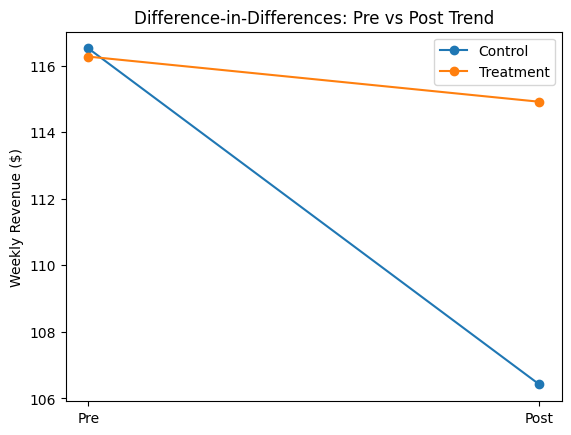

In [11]:
trend = panel_df.groupby(["pre_post_flag", "treatment_flag"])["revenue_sim"].mean().reset_index()

plt.figure()
for group in [0, 1]:
    subset = trend[trend["treatment_flag"] == group].copy()
    subset["x"] = subset["pre_post_flag"].map({"pre": 0, "post": 1})
    subset = subset.sort_values("x")
    plt.plot(subset["x"], subset["revenue_sim"], marker="o", label=("Control" if group == 0 else "Treatment"))

plt.xticks([0, 1], ["Pre", "Post"])
plt.title("Difference-in-Differences: Pre vs Post Trend")
plt.ylabel("Weekly Revenue ($)")
plt.legend()
plt.show()

Pre/post averages provide a limited parallel-trends sanity check (two time points). We rely on randomization for identification; DiD is included as a robustness check for time effects.

## 7.1 Clustered DiD

In [12]:
import statsmodels.api as sm

X_did = panel_df[["treatment_flag", "post", "interaction"]]
X_did = sm.add_constant(X_did)
y_did = panel_df["revenue_sim"]

did_cluster = sm.OLS(y_did, X_did).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_df["user_id"]}
)

In [13]:
did_res = coef_line(did_cluster)
print(
    f"Clustered DiD weekly lift (interaction): ${did_res['coef']:.2f} "
    f"(95% CI: ${did_res['ci_low']:.2f}, ${did_res['ci_high']:.2f})"
)

Clustered DiD weekly lift (interaction): $8.74 (95% CI: $7.90, $9.59)


**Interpretation:**  
The interaction coefficient (β₃) is positive and statistically significant: treated users experienced ~$8.74 higher weekly revenue growth relative to control from pre to post.

## 7.2 Fixed Effects DiD
To control for time-invariant user heterogeneity, we estimate a fixed-effects DiD model using within-user demeaning.

In [14]:
X_fe = panel_df[["post", "interaction"]]
X_fe = sm.add_constant(X_fe)
y_fe = panel_df["revenue_demeaned"]

fe_cluster = sm.OLS(y_fe, X_fe).fit(
    cov_type="cluster",
    cov_kwds={"groups": panel_df["user_id"]}
)

In [15]:
fe_res = coef_line(fe_cluster)
print(
    f"Fixed Effects DiD weekly lift (interaction): ${fe_res['coef']:.2f} "
    f"(95% CI: ${fe_res['ci_low']:.2f}, ${fe_res['ci_high']:.2f})"
)

Fixed Effects DiD weekly lift (interaction): $4.53 (95% CI: $4.13, $4.93)


**Interpretation:**  
With user fixed effects, the incremental lift remains positive (~$4.53/week), indicating some user-level heterogeneity was previously contributing to estimated lift.


## 7.3 Model Comparison

In [16]:
did_res = coef_line(did_cluster)
fe_res = coef_line(fe_cluster)

results_table = pd.DataFrame({
    "Model": ["DiD Clustered", "FE DiD Clustered"],
    "Lift ($)": [did_res["coef"], fe_res["coef"]],
    "CI Lower": [did_res["ci_low"], fe_res["ci_low"]],
    "CI Upper": [did_res["ci_high"], fe_res["ci_high"]],
})

results_table

,Model,Lift ($),CI Lower,CI Upper
0,DiD Clustered,8.74,7.90,9.59
1,FE DiD Clustered,4.53,4.13,4.93


Both specifications show statistically significant positive lift. The smaller fixed-effects estimate suggests that part of the naive DiD estimate reflects time-invariant user differences, but the treatment effect remains economically meaningful.

## 8. Heterogeneous Treatment Effects

Estimate treatment lift by baseline spend quartile to evaluate whether promotion impact differs across user segments.

In [17]:
query_pre = """
select
    user_id,
    treatment_flag,
    pre_revenue
from (
    select
        user_id,
        treatment_flag,
        sum(revenue) as pre_revenue
    from marts.mart_user_week_experiment_sim
    where high_ltv_flag = 1
      and pre_post_flag = 'pre'
    group by 1,2
) t
"""

pre_df = pd.read_sql(query_pre, conn)
pre_df.head()

C:\Users\trist\AppData\Local\Temp\ipykernel_13684\2374370851.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pre_df = pd.read_sql(query_pre, conn)


,user_id,treatment_flag,pre_revenue
0,3006,1,378.40
1,51835,0,552.47
2,1789,0,718.54
3,93043,0,513.00
4,22120,1,367.78


In [18]:
hte_df = df.merge(pre_df, on=["user_id", "treatment_flag"], how="inner")
hte_df.head()

,user_id,treatment_flag,post_revenue,pre_revenue
0,2,1,318.3516,304.18
1,10,1,662.5908,335.56
2,11,0,64.0100,288.80
3,17,0,327.7300,479.04
4,19,0,442.8600,643.05


In [19]:
hte_df["baseline_quartile"] = pd.qcut(
    hte_df["pre_revenue"],
    4,
    labels=["Q1 Low", "Q2", "Q3", "Q4 High"]
)

hte_df[["pre_revenue", "baseline_quartile"]].head()

,pre_revenue,baseline_quartile
0,304.18,Q1 Low
1,335.56,Q2
2,288.80,Q1 Low
3,479.04,Q3
4,643.05,Q4 High


In [20]:
hte_summary = (
    hte_df.groupby(["baseline_quartile", "treatment_flag"])["post_revenue"]
    .mean()
    .unstack()
    .reset_index()
)

hte_summary.columns = ["baseline_quartile", "control_mean", "treatment_mean"]
hte_summary["lift"] = hte_summary["treatment_mean"] - hte_summary["control_mean"]
hte_summary["pct_lift"] = hte_summary["lift"] / hte_summary["control_mean"] * 100

hte_summary = hte_summary.round(2)
hte_summary

,baseline_quartile,control_mean,treatment_mean,lift,pct_lift
0,Q1 Low,224.66,243.74,19.08,8.49
1,Q2,269.44,289.65,20.21,7.50
2,Q3,340.26,371.22,30.96,9.10
3,Q4 High,561.64,608.48,46.84,8.34


In [21]:
import numpy as np

hte_ci = (
    hte_df.groupby(["baseline_quartile", "treatment_flag"])["post_revenue"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

hte_ci["se"] = hte_ci["std"] / np.sqrt(hte_ci["count"])

In [22]:
control = hte_ci[hte_ci["treatment_flag"] == 0]
treatment = hte_ci[hte_ci["treatment_flag"] == 1]

lift_df = control[["baseline_quartile", "mean", "se"]].merge(
    treatment[["baseline_quartile", "mean", "se"]],
    on="baseline_quartile",
    suffixes=("_control", "_treat")
)

lift_df["lift"] = lift_df["mean_treat"] - lift_df["mean_control"]
lift_df["se_lift"] = np.sqrt(lift_df["se_control"]**2 + lift_df["se_treat"]**2)
lift_df["ci_low"] = lift_df["lift"] - 1.96 * lift_df["se_lift"]
lift_df["ci_high"] = lift_df["lift"] + 1.96 * lift_df["se_lift"]

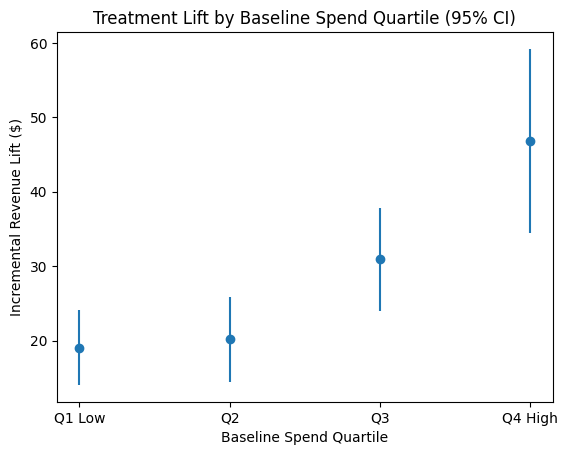

In [23]:
import matplotlib.pyplot as plt

plt.figure()

plt.errorbar(
    lift_df["baseline_quartile"],
    lift_df["lift"],
    yerr=1.96 * lift_df["se_lift"],
    fmt='o'
)

plt.title("Treatment Lift by Baseline Spend Quartile (95% CI)")
plt.xlabel("Baseline Spend Quartile")
plt.ylabel("Incremental Revenue Lift ($)")

plt.show()

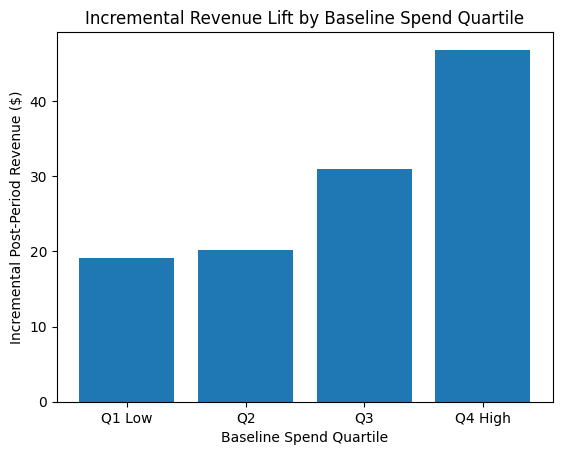

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(hte_summary["baseline_quartile"], hte_summary["lift"])
plt.title("Incremental Revenue Lift by Baseline Spend Quartile")
plt.ylabel("Incremental Post-Period Revenue ($)")
plt.xlabel("Baseline Spend Quartile")
plt.show()

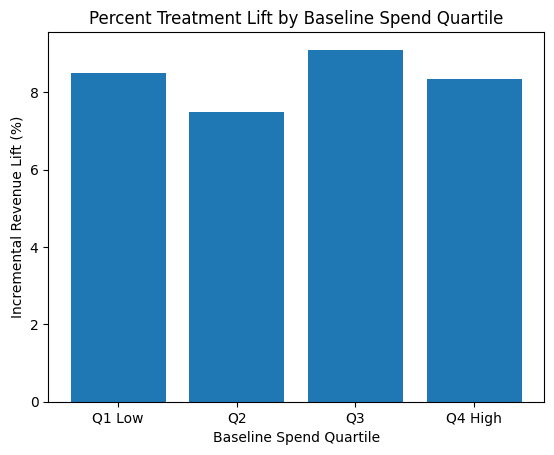

In [25]:
plt.figure()
plt.bar(hte_summary["baseline_quartile"], hte_summary["pct_lift"])
plt.title("Percent Treatment Lift by Baseline Spend Quartile")
plt.ylabel("Incremental Revenue Lift (%)")
plt.xlabel("Baseline Spend Quartile")
plt.show()

**Interpretation:**  
Treatment lift is positive across all baseline spend quartiles, but the largest absolute lift appears in the highest-value users. This suggests the promotion is broadly effective while generating the strongest dollar impact among users with higher historical spend, supporting targeted discounting for high-LTV segments.

## Business Implications

The 10% targeted discount generates statistically significant incremental revenue among high-LTV users.

Even under conservative fixed-effects estimates, the promotion drives meaningful weekly incremental revenue ($4.53).

Results indicate targeted discounts for high-LTV users generate statistically robust incremental revenue, even after controlling for user-level heterogeneity and time trends.

If scaled to 100,000 high-LTV users, the estimated incremental revenue would be approximately $2.7–2.9M over six weeks.

## Limitations & Future Work

- Only two time periods (pre/post) limit formal parallel trends validation.

- Simulation-based revenue assumptions; real-world deployment would require monitoring for discount cannibalization and long-term retention effects.

- Future work: heterogeneous treatment effects by user tenure or prior spend.

---

# Appendix

## A1. Clustered Difference-in-Differences Model

Focus on the interaction coefficient and its clustered standard error / 95% CI. 

Full regression output for baseline DiD specification with cluster-robust standard errors at the user level.


In [26]:
print(did_cluster.summary())

                            OLS Regression Results                            
Dep. Variable:            revenue_sim   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     431.1
Date:                Sun, 08 Mar 2026   Prob (F-statistic):          3.31e-277
Time:                        23:08:07   Log-Likelihood:            -2.5086e+06
No. Observations:              440501   AIC:                         5.017e+06
Df Residuals:                  440497   BIC:                         5.017e+06
Df Model:                           3                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            116.5163      0.317    367.

The interaction coefficient represents incremental weekly lift for treatment users relative to control, controlling for time effects.

## A2. Fixed Effects Difference-in-Differences Model

Focus on interaction. 

User-level fixed effects implemented via within transformation (demeaned revenue), with cluster-robust standard errors.

In [27]:

print(fe_cluster.summary())

                            OLS Regression Results                            
Dep. Variable:       revenue_demeaned   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1057.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        23:08:07   Log-Likelihood:            -2.3644e+06
No. Observations:              440501   AIC:                         4.729e+06
Df Residuals:                  440498   BIC:                         4.729e+06
Df Model:                           2                                         
Covariance Type:              cluster                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.7367      0.072     38.117      

The fixed-effects specification removes time-invariant user heterogeneity. The interaction term remains statistically significant.